<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment/blob/main/ESAA_YB_WEEK4_study_0323.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#2. 사이킷런으로 시작하는 머신러닝
(p.85~115)

##2.1 사이킷런 소개와 특징
- 쉽고 가장 파이썬스러운 API 제공
- 머신러닝을 위한 매우 다양한 알고리즘과 개발을 위한 편리한 프레임워크와 API 제공
- 오랜 기간 실전 환경에서 검증됐으며, 매우 많은 환경에서 사용되는 성숙한 라이브러리

In [2]:
#pip install scikit-learn==1.0.2

import sklearn

print(sklearn.__version__)

1.6.1


##2.2 머신러닝1. 분류: 붓꽃 품종 예측하기
- 피처: 꽃잎의 길이와 너비, 꽃받침의 길이와 너비
- 피처를 기반으로 꽃의 품종 예측

- 분류
  - 대표적인 지도학습 방법
  - 학습을 위한 다양한 Feature와 분류 결정값인 Label 데이터로 모델을 학습한 뒤, 별도의 테스트 데이터 세트에서 미지의 레이블 예측
  - 학습 데이터 세트: 주어진 데이터 세트
  - 테스트 데이터 세트: 머신러닝 모델의 예측 성능을 평가하기 위해 별도로 주어진 데이터 세트 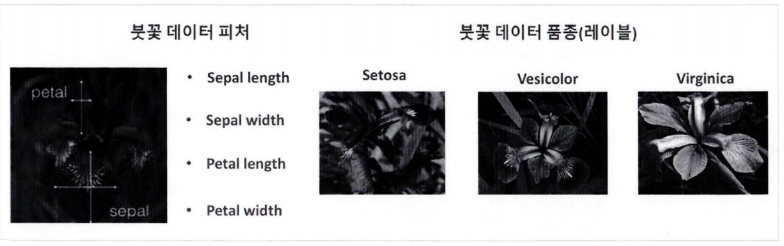

In [3]:
from sklearn.datasets import load_iris #사이킷런에서 자체적으로 제공하는 데이터 세트를 생성하는 모듈의 모임
from sklearn.tree import DecisionTreeClassifier #트리 기반 ML 알고리즘을 구현한 클래스 모임
from sklearn.model_selection import train_test_split
#학습데이터와 검증데이터, 예측데이터로 데이터를 분리하거나 최적의 하이퍼 파라미터로 평가하기 위한 다양한 모듈의 모임
#하이퍼 파라미터: 머신러닝 알고리즘별로 최적의 학습을 위해 직접 입력하는 파라미터

###데이터 세트 로딩

In [4]:
import pandas as pd

# 붓꽃 데이터 세트를 로딩합니다.
iris = load_iris()

# iris.data는 Iris 데이터 세트에서 피처(feature)만으로 된 데이터를 numpy로 가지고 있습니다.
iris_data = iris.data

# iris.target은 붓꽃 데이터 세트에서 레이블(결정 값) 데이터를 numpy로 가지고 있습니다.
iris_label = iris.target
print('iris target값:', iris_label)
print('iris target명:', iris.target_names)

# 붓꽃 데이터 세트를 자세히 보기 위해 DataFrame으로 변환합니다.
iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)
iris_df['label'] = iris.target
iris_df.head(3)

iris target값: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
iris target명: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


### 분류 예측 프로세스
1. 데이터 세트 분리
- 데이터를 학습 데이터와 테스트 데이터로 분리

2. 모델 학습
- 학습 데이터를 기반으로 ML 알고리즘을 적용해 모델 학습

3. 예측 수행
- 학습된 ML 모델을 이용해 테스트 데이터의 분류(즉, 붓꽃 종류)를 예측

4. 평가
- 예측된 결과값과 테스트 데이터의 실제 결과값을 비교해 ML 모델 성능 평가

In [5]:
# 학습용 데이터와 테스트용 데이터 분리
#train_test_split()
#test_size 파라미터 입력값의 비율로 분할
#예: 0.2-> 테스트:학습 = 2:8
X_train, X_test, y_train, y_test = train_test_split(iris_data, iris_label, test_size=0.2, random_state=11)

의사 결정 트리
- 학습 데이터를 기반으로 학습
- 학습된 객체 + 테스트 데이터 세트 이용해 예측 수행

In [6]:
# DecisionTreeClassifier 객체 생성
dt_clf = DecisionTreeClassifier(random_state=11)

#학습 수행
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=11)

In [7]:
# 학습이 완료된 DecisionTreeClassifier 객체에서 테스트 데이터 세트로 예측 수행.
pred = dt_clf.predict(X_test)

In [8]:
# 예측 성능 평가 accuracy_score()
# 정확도 측정: 예측 결과가 실제 레이블 값과 얼마나 정확하게 맞는지
from sklearn.metrics import accuracy_score
print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test,pred)))

예측 정확도: 0.9333


##2.3 사이킷런의 기반 프레임워크 익히기

###Estimator 이해 및 fit(), predict() 메서드
- fit(): ML 모델 학습
- predict(): 학습된 모델의 예측
- Estimator 클래스: 지도학습의 모든 알고리즘을 구현한 클래스(분류-Classifier, 회귀-Regressor)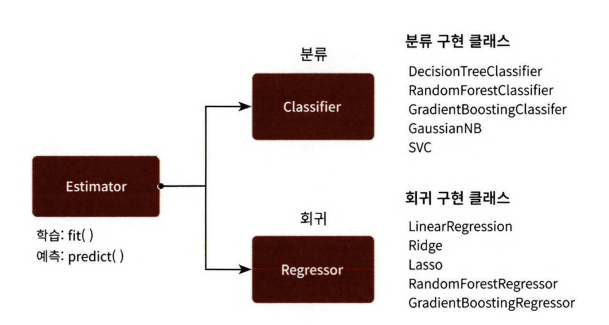

- 비지도학습: 차원 축소, 클러스터링, 피처 추출 -> fit(), transform() 적용
- fit(): 입력 데이터의 형태에 맞춰 데이터를 변환하기 위한 사전 구조를 맞추는 작업
- transform(): 입력 데이터의 차원 변환, 클러스터링, 피처 추출

###사이킷런의 주요 모듈
[예제 데이터]

- sklearn.datasets: 사이킷런에 내장되어 에제로 제공하는 데이터 세트

[피처 처리]

- sklearn.preprocessing: 데이터 전처리에 필요한 다양한 가공 기능 제공(문자열을 숫자형 코드 값으로 인코딩, 정규화, 스케일링 등)

- sklearn.feature_selection: 알고리즘에 큰 영향을 미치는 피처를 우선순위대로 셀렉션 작업을 수행하는 다양한 기능 제공

- sklearn.feature_extraction: 텍스트 데이터나 이미지 데이터의 벡터화된 피처를 추출하는데 사용됨

[피처 처리 & 차원 축소]

- sklearn.decomposition: 차원 축소와 관련한 알고리즘을 지원하는 모듈

[데이터 분리, 검증 & 파라미터 튜닝]

- sklearn.model_selection: 교차 검증을 위한 학습용/테스트용 분리

[평가]

- sklearn.metrics: 분류, 회귀, 클러스터링, 페어와이즈에 대한 다양한 성능 측정 방법 제공

[ML 알고리즘]

- sklearn.ensemble: 앙상블 알고리즘 제공
-sklearn.limear_model: 주로 선형회귀, 릿지, 라쏘 및 로지스틱 회귀 등 회귀 관련 알고리즘 지원. SGD 관련 알고리즘도 제공
- sklearn.naive_bayes: 나이브 베이즈 알고리즘 제공.
- sklearn.neighbors: 최근접 이웃 알고리즘 제공
- sklearn.svm: 서포트 벡터 머신 알고리즘 제공
- sklearn.tree: 의사결정트리 알고리즘 제공
- sklearn.cluster: 비지도 클러스터링 알고리즘 제공

[유틸리티]

-sklearn.pipeline: 피처 처리 등의 변환과 ML 알고리즘 학습, 예측 등을 함께 묶어서 실행할 수 있는 유틸리티 제공



###내장된 예제 데이터 세트
- 사이킷런 내장 데이터 세트 존재
  - 분류나 회귀를 연습하기 위한 예제용도의 데이터 세트
  - 분류나 클러스터링을 위해 표본 데이터로 생성될 수 있는 데이터 세트

[분류나 회귀 연습용 예제 데이터]

- datasets.load_boston(): 회귀 용도. 미국 보스턴의 집 피처들과 가격에 대한 데이터 세트

- datasets.load_breast_cancer(): 분류 용도. 위스콘신 유방암 피처들과 악성/음성 레이블 데이터 세트

- datasets.load_diabates(): 회귀 용도. 당뇨 데이터 세트

- datasets.load_digits() = 분류 용도. 0~9까지의 숫자의 이미지 픽셀 데이터 세트

- datasets.load_iris(): 분류 용도. 붓꽃에 대한 피처를 가진 데이터 세트
- fetch 계열의 명령
  - 데이터의 크기가 커서 패키지에 처음부터 저장되어 있지 않고, 인터넷에서 내려 받아 불러들이는 데이터 (최초 사용 시 인터넷 연결 필수)
  -  fetch_covtype(): 회귀 분석용 토지 조사 자료
  - fetch_20newsgroups (): 뉴스 그룹 텍스트 자료
  - fetch_olivetti_faces(): 얼굴 이미지 자료
  - fetch_lfw_people(): 얼굴 이미지 자료
  - fetch_lfw_pairs(): 얼굴 이미지 자료
  - fetch_rcv1(): 로이터뉴스 말뭉치
  - fetch_mldata(): ML 웹사이트에서 다운로드

In [9]:
from sklearn.datasets import load_iris

iris_data = load_iris()
print(type(iris_data)) #딕셔너리 형태

<class 'sklearn.utils._bunch.Bunch'>


In [11]:
keys = iris_data.keys()
print('붓꽃 데이터 세트의 키들:', keys)

붓꽃 데이터 세트의 키들: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


- 데이터 키 = 피처들의 데이터 값
- 피처 데이터 값을 추출하는 법:
  - 데이터 세트.data
  - 데이터 세트['data']

In [14]:
print('\n feature_names의 type:', type(iris_data.feature_names))
print('feature_names의 shape:', len(iris_data.feature_names))
print(iris_data.feature_names)

print('\n target_names의 type:', type(iris_data.target_names))
print('target_names의 shape:', len(iris_data.target_names))
print(iris_data.target_names)

print('\n data의 type:', type(iris_data.data))
print('data의 shape:', iris_data.data.shape)
print(iris_data['data'])

print('\n target의 type:', type(iris_data.target))
print('target의 shape:', iris_data.target.shape)
print(iris_data.target)


 feature_names의 type: <class 'list'>
feature_names의 shape: 4
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

 target_names의 type: <class 'numpy.ndarray'>
target_names의 shape: 3
['setosa' 'versicolor' 'virginica']

 data의 type: <class 'numpy.ndarray'>
data의 shape: (150, 4)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 

[분류와 클러스터링을 위한 표본 데이터 생성기]

- datasets.make_classifications(): 분류
- datasets.make_blobs(): 클러스터링

##2.4 Model Selection 모듈 소개
- 학습 데이터와 테스트 데이터 세트를 분리
- 교차 검증 분할 및 평가
- Estimator의 하이퍼 파라미터를 튜닝하기 위한 다양한 함수와 클래스 제공

###학습/테스트 데이터 세트 분리 - train_test_split()

In [15]:
# 학습 데이터 세트로만 학습하고 예측하면 무엇이 문제인지
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
dt_clf = DecisionTreeClassifier()
train_data = iris.data
train_label = iris.target
dt_clf.fit(train_data, train_label)

# 학습 데이터 세트로 예측 수행
pred = dt_clf.predict(train_data)
print('예측 정확도:', accuracy_score(train_label, pred))

예측 정확도: 1.0


1. sklearn.model_selection 모듈에서 train_test_split 로드
- train_test_split()은 첫 번째 파라미터로 피러 데이터 세트, 두 번째 파라미터로 레이블 데이터 세트를 입력받음

2. 선택적으로 다음 파라미터를 입력받음
- test_size
- train_size
- shuffle
- random_state

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

dt_clf = DecisionTreeClassifier()
iris_data = load_iris()

X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target,
                                                    test_size=0.3, random_state=121)

In [17]:
dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)
print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

예측 정확도: 0.9556


###교차 검증
- 과적합(Overfitting): 모델이 학습 데이터에만 과도하게 최적화되어, 실제 예측을 다른 데이터로 수행할 경우 예측 성능이 과도하게 떨어지는 것.
- 테스트 데이터에만 최적의 성능을 발휘할 수 있도록 편향되게 모델을 유도하는 경향

=> 교차검증!!!

- 여러 세트로 구성된 학습 데이터 세트와 검증 데이터 세트에서 학습과 평가를 수행하는 것.
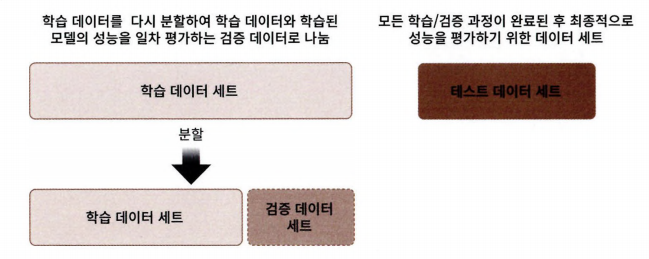

####K 폴드 교차 검증
- K개의 데이터 폴드 세트를 만들어서 K번만큼 각 폴트 세트에 학습과 검증 평가를 반복적으로 수행하는 방법
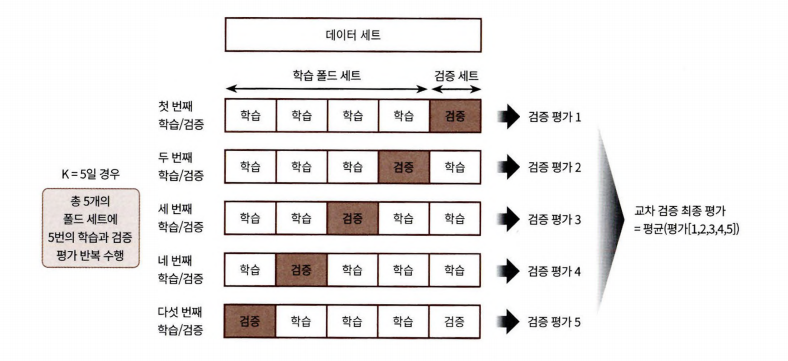

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np

iris = load_iris()
features = iris.data
label = iris.target
dt_clf = DecisionTreeClassifier(random_state=156)

# 5개의 폴드 세트로 분리하는 KFold 객체와 폴드 세트별 정확도를 담을 리스트 객체 생성.
kfold = KFold(n_splits=5)
cv_accuracy = []
print('붓꽃 데이터 세트 크기:', features.shape[0])

붓꽃 데이터 세트 크기: 150


- 학습용 데이터 세트: 120개(4/5)
- 검증 테스트 데이터 세트: 30개(1/5)

In [20]:
n_iter=0

# KFold 객체의 split()를 호출하면 폴드별 학습용, 검증용 테스트의 로우 인덱스를 array로 반환
for train_index, test_index in kfold.split(features):
  # kfold.split( )으로 반환된 인덱스를 이용해 학습용, 검증용 테스트 데이터 추출
  X_train, X_test = features[train_index], features[test_index]
  y_train, y_test = label[train_index], label[test_index]
  # 학습 및 예측
  dt_clf.fit(X_train, y_train)
  pred = dt_clf.predict(X_test)
  n_iter += 1
  # 반복 시마다 정확도 측정
  accuracy = np.round(accuracy_score(y_test, pred), 4)
  train_size = X_train.shape[0]
  test_size = X_test.shape[0]
  print('\n#{0} 교차 검증 정확도: {1}, 학습 데이터 크기: {2}, 검증 데이터 크기: {3}'.format(n_iter, accuracy, train_size, test_size))
  print('#{0} 검증 세트 인덱스: {1}'.format(n_iter, test_index))
  cv_accuracy.append(accuracy)

# 개별 iteration별 정확도를 합하여 평균 정확도 계산
print('\n## 평균 검증 정확도:', np.mean(cv_accuracy))


#1 교차 검증 정확도: 1.0, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#1 검증 세트 인덱스: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

#2 교차 검증 정확도: 0.9667, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#2 검증 세트 인덱스: [30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53
 54 55 56 57 58 59]

#3 교차 검증 정확도: 0.8667, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#3 검증 세트 인덱스: [60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89]

#4 교차 검증 정확도: 0.9333, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#4 검증 세트 인덱스: [ 90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]

#5 교차 검증 정확도: 0.7333, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#5 검증 세트 인덱스: [120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149]

## 평균 검증 정확도: 0.9


####Stratified K 폴드
- 불균형한(imbalanced) 분포도를 가진 레이블(결정 클래스) 데이터 집합을 위한 K 폴드 방식
- 특정 레이블 값이 특이하게 많거나 매우 적어서 값의 분포가 한쪽으로 치우치는 것을 말함.
- 예: 대출 사기 데이터 -> 0.00001%의 작은 확률로 대출 사기 레이블이 존재

=> 원본 데이터의 레이블 분포를 먼지 고려한 뒤 이 분포와 동일하게 학습과 검증 데이터 세트를 분배

In [21]:
import pandas as pd

iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['label']=iris.target
iris_df['label'].value_counts()

,count
label,
0,50
1,50
2,50


In [24]:
#KFold로 분할 후 StratifiedKFold로 학습/검증 분포도 확인
kfold = KFold(n_splits=3)
n_iter = 0
for train_index, test_index in kfold.split(iris_df):
  n_iter += 1
  label_train = iris_df['label'].iloc[train_index]
  label_test = iris_df['label'].iloc[test_index]
  print('## 교차 검증: {0}'.format(n_iter))
  print('학습 레이블 데이터 분포:\n', label_train.value_counts())
  print('검증 레이블 데이터 분포:\n', label_test.value_counts())

## 교차 검증: 1
학습 레이블 데이터 분포:
 label
1    50
2    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    50
Name: count, dtype: int64
## 교차 검증: 2
학습 레이블 데이터 분포:
 label
0    50
2    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
1    50
Name: count, dtype: int64
## 교차 검증: 3
학습 레이블 데이터 분포:
 label
0    50
1    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
2    50
Name: count, dtype: int64


In [27]:
# Stratified KFold로 분할 후 학습/검증 분포도 확인
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=3)
n_iter=0

for train_index, test_index in skf.split(iris_df, iris_df['label']):
  n_iter += 1
  label_train = iris_df['label'].iloc[train_index]
  label_test = iris_df['label'].iloc[test_index]
  print('## 교차 검증: {0}'.format(n_iter))
  print('학습 레이블 데이터 분포:\n', label_train.value_counts())
  print('검증 레이블 데이터 분포:\n', label_test.value_counts())

## 교차 검증: 1
학습 레이블 데이터 분포:
 label
2    34
0    33
1    33
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    17
1    17
2    16
Name: count, dtype: int64
## 교차 검증: 2
학습 레이블 데이터 분포:
 label
1    34
0    33
2    33
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    17
2    17
1    16
Name: count, dtype: int64
## 교차 검증: 3
학습 레이블 데이터 분포:
 label
0    34
1    33
2    33
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
1    17
2    17
0    16
Name: count, dtype: int64


- 레이블 값별로 거의 동일하게 할당됨.
- 이렇게 분할이 되어야 레이블 값 0, 1, 2 를 모두 학습할 수 있고, 이에 기반해 검증을 수행할 수 있음.

In [29]:
dt_clf = DecisionTreeClassifier(random_state=156)

skfold = StratifiedKFold(n_splits=3)
n_iter=0
cv_accuracy=[]

# StratifiedKFold의 split() 호출시 반드시 레이블 데이터 세트도 추가 입력 필요
for train_index, test_index in skfold.split(features, label):
  # split()으로 반환된 인덱스를 이용해 학습용, 검증용 테스트 데이터 추출
  X_train, X_test = features[train_index], features[test_index]
  y_train, y_test = label[train_index], label[test_index]
  # 학습 및 예측
  dt_clf.fit(X_train, y_train)
  pred = dt_clf.predict(X_test)

  # 반복 시마다 정확도 측정
  n_iter += 1
  accuracy = np.round(accuracy_score(y_test, pred), 4)
  train_size = X_train.shape[0]
  test_size = X_test.shape[0]
  print('\n#{0} 교차 검증 정확도: {1}, 학습 데이터 크기: {2}, 검증 데이터 크기: {3}'.format(n_iter, accuracy, train_size, test_size))
  print('#{0} 검증 세트 인덱스: {1}'.format(n_iter, test_index))
  cv_accuracy.append(accuracy)

  # 교차 검증별 정확도 및 평균 정확도 계산
  print('\n## 교차 검증별 정확도:', np.round(cv_accuracy, 4))
  print('## 평균 검증 정확도:', np.round(np.mean(cv_accuracy), 4))


#1 교차 검증 정확도: 0.98, 학습 데이터 크기: 100, 검증 데이터 크기: 50
#1 검증 세트 인덱스: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  50
  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66 100 101
 102 103 104 105 106 107 108 109 110 111 112 113 114 115]

## 교차 검증별 정확도: [0.98]
## 평균 검증 정확도: 0.98

#2 교차 검증 정확도: 0.94, 학습 데이터 크기: 100, 검증 데이터 크기: 50
#2 검증 세트 인덱스: [ 17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82 116 117 118
 119 120 121 122 123 124 125 126 127 128 129 130 131 132]

## 교차 검증별 정확도: [0.98 0.94]
## 평균 검증 정확도: 0.96

#3 교차 검증 정확도: 0.98, 학습 데이터 크기: 100, 검증 데이터 크기: 50
#3 검증 세트 인덱스: [ 34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149]

## 교차 검증별 정확도: [0.98 0.94 0.98]
## 평균 검증 정확도: 0.9667


- 원본 데이터의 레이블 분포도 특성을 반영한 학습 및 검증 데이터 세트를 만들 수 있으므로 왜곡된 레이블 데이터 세트에서는 반드시 Stratified K 폴드를 이용해 교차 검증해야 함.
- 일반적으로 분류(Classification)에서의 교차 검증은 K 폴드가 아니라 Stratified K 폴드로 분할
- 회귀(Regression)에서는 Stratified K 폴드가 지원되지 않음.
<= 회귀의 결정값은 이산값 형태의 레이블이 아니라 연속된 숫자값이기 때문

####교차 검증을 보다 간편하게 - cross_val_score()
- 일련의 과정을 한꺼번에 수행
  - 1 폴드 세트를 설정
  - 2 for 루프에서 반복으로 학습 및 테스트 데이터의 인덱스를 추출한 뒤
  - 3 반복적으로 학습과 예측을 수행하고 예측 성능을 반환

- cross_yal_score() 수행 후 반환 값은 scoring 파라미
터로 지정된 성능 지표 측정값을 배열 형태로 반환
- cross_val_score()는 classifier가 입력되면 Stratified K 폴드 방식으로 레이블값의 분포에 따라 학습/테스트 세트를 분할
- 회귀인 경우는 Stratified K 폴드 방식으로 분할할 수 없으므로 K 폴드 방식으로 분할.

In [ ]:
cross_val_score(estimator, X, y=None, scoring=None, cv=None,
                n_jobs=1, verbose=0, fit_params=None, pre_dispatch='2*n_jobs')
# 이 중 estimator, X, y, scoring, cv가 주요 파라미터

- estimator: 사이킷런의 분류 알고리즘 클래스인 Classifier 또는 회귀 알고리즘 클래스인 Regressor
- X는 피처 데이터 세트, y는 레이블 데이터 세트
- scoring: 예측 성능 평가 지표
- cv: 교차 검증 폴드 수


In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.datasets import load_iris

iris_data = load_iris()
dt_clf = DecisionTreeClassifier(random_state=156)

data = iris_data.data
label = iris_data.target

# 성능 지표는 정확도(accuracy), 교차 검증 세트는 3개
scores = cross_val_score(dt_clf, data, label, scoring='accuracy', cv=3)
print('교차 검증별 정확도:', np.round(scores, 4))
print('평균 검증 정확도:', np.round(np.mean(scores), 4))

교차 검증별 정확도: [0.98 0.94 0.98]
평균 검증 정확도: 0.9667


- 붓꽃 데이터의 cross_val_score() 수행 결과와 앞 예제의 붓꽃 데이터 StratifiedKFold의 수행 결과를 비교해 보면 각 교차 검증별 정확도와 평균 검증 정확도가 모두 동일함.
- cross_val_score()가 내부적으로 StratifiedKFold를 이용하기 때문
- cross_validate()
  - 여러 개의 평가 지표를 반환(cross_val_score()는 단 하나의 평가 지표만 가능)
  - 학습 데이터에 대한 성능 평가 지표와 수행 시간도 같이 제공

###GridSearchCV - 교차 검증과 최적 하이퍼 파라미터 튜닝을 한 번에
- 하이퍼 파라미터를 순차적으로 입력하면서 편리하게 최적의 파라미터를 도출할 수 있는 방안을 제공
(Grid는 격자라는 뜻으로, 촘촘하게 파라미터를 입력하면서 테스트를 하는 방식)

In [35]:
grid_parameters = {'max_depth': [1,2,3],
                   'min_samples_split': [2,3]}
grid_parameters

{'max_depth': [1, 2, 3], 'min_samples_split': [2, 3]}

- 총 6회에 걸쳐 파라미터를 순차적으로 바꿔 실행하면서 최적의 파라미터와 수행 결과를 도출할 수 있음.
- 교차 검증을 기반으로 이 하이퍼 파라미터의 최적 값을 찾게 해줌.
- 수행시간 오래 걸림.
- CV 3회 x 6개 파라미터 조합 = 18회의 학습/평가

In [36]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# 데이터를 로딩하고 학습 데이터와 테스트 데이터 분리
iris_data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target,
                                                    test_size=0.2, random_state=121)
dtree = DecisionTreeClassifier()

### 파라미터를 딕셔너리 형태로 설정
parameters = {'max_depth': [1,2,3], 'min_samples_split': [2,3]}

In [37]:
import pandas as pd

# param_grid의 하이퍼 파라미터를 3개의 train, test set fold로 나누어 테스트 수행 설정.
### refit=True가 default임. True이면 가장 좋은 파라미터 설정으로 재학습시킴.
grid_dtree = GridSearchCV(dtree, param_grid=parameters, cv=3, refit=True)

# 붓꽃 학습 데이터로 param_grid의 하이퍼 파라미터를 순차적으로 학습/평가.
grid_dtree.fit(X_train, y_train)

# GridSearchCV 결과를 추출해 DataFrame으로 변환
scores_df = pd.DataFrame(grid_dtree.cv_results_)
scores_df[['params', 'mean_test_score', 'rank_test_score',
           'split0_test_score', 'split1_test_score', 'split2_test_score']]

,params,mean_test_score,rank_test_score,split0_test_score,split1_test_score,split2_test_score
0,"{'max_depth': 1, 'min_samples_split': 2}",0.700000,5,0.700,0.7,0.70
1,"{'max_depth': 1, 'min_samples_split': 3}",0.700000,5,0.700,0.7,0.70
2,"{'max_depth': 2, 'min_samples_split': 2}",0.958333,3,0.925,1.0,0.95
3,"{'max_depth': 2, 'min_samples_split': 3}",0.958333,3,0.925,1.0,0.95
4,"{'max_depth': 3, 'min_samples_split': 2}",0.975000,1,0.975,1.0,0.95
5,"{'max_depth': 3, 'min_samples_split': 3}",0.975000,1,0.975,1.0,0.95


4, 5번 행이 mean_test_score 값이 0.975000로 가장 높음. (1위)

In [38]:
print('GridSearchCV 최적 파라미터:', grid_dtree.best_params_)
print('GridSearchCV 최고 정확도:{0:.4f}'.format(grid_dtree.best_score_))

GridSearchCV 최적 파라미터: {'max_depth': 3, 'min_samples_split': 2}
GridSearchCV 최고 정확도:0.9750


- refit=True가 디폴트
- refit=True이면 GridSearchCV가 최적 성능을 나타내는 하이퍼 파라미터로 Estimator를 학습해 best_estimator_로
저장

In [39]:
# gridSearchCV의 refit으로 이미 학습된 estimator 반환
estimator = grid_dtree.best_estimator_

# GridSearchCV의 best_estimator_는 이미 최적 학습이 됐으므로 별도 학습이 필요 없음
pred = estimator.predict(X_test)
print('테스트 데이터 세트 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

테스트 데이터 세트 정확도: 0.9667


학습 데이터를 GridSearchCV를 이용해 최적 하이퍼 파라미터 튜닝을 수행한 뒤에 별도의 테스트 세트에서 이를 평가하는 것이 일반적인 머신러닝 모델 적용 방법